# Laboratory 3 - Hypothesis Testing in Network Analysis

## Email-Eu-core Network

### Laboratory Task

The purpose of this laboratory is to apply inferential network analysis to a real network dataset and determine whether an observed network pattern is unusual relative to an explicitly defined reference model.

The analysis follows the workflow:

**Research question → Network representation → Network mechanism → Hypotheses → Null model → Statistical test → Interpretation**

For this laboratory, the **Email-Eu-core Network** used in Laboratory 2 is analysed again.

The network mechanism investigated is **homophily**.

## 1.1 Dataset Description

The **Email-Eu-core Network** is a publicly available network dataset from the Stanford Large Network Dataset Collection (SNAP).

The dataset represents email communication between members of a European research institution. A node represents an individual member, while a directed edge represents an email relationship from one member to another.

The network contains **1,005 nodes** and **25,571 directed email relationships**. The dataset also provides department labels for the nodes, with **42 different departments**.

The network is treated as **directed and unweighted**. The department labels are used to investigate **homophily**, specifically whether members of the same department are connected by email more frequently than would be expected under a random assignment of department labels.

The dataset does not provide a specific observation window for the email relationships, so the analysis treats the available network as a single observed network.

The analysis is carried out in Python using **Pandas, NetworkX, NumPy, and Matplotlib**.

In [2]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

In [4]:
edges = pd.read_csv(
    "/content/sample_data/email-Eu-core.txt",
    sep=r"\s+",
    header=None,
    names=["source", "target"]
)

labels = pd.read_csv(
    "/content/sample_data/email-Eu-core-department-labels.txt",
    sep=r"\s+",
    header=None,
    names=["node", "department"]
)

print("Email records:", len(edges))
print("Labelled nodes:", len(labels))
print("Departments:", labels["department"].nunique())

Email records: 25571
Labelled nodes: 1005
Departments: 42


In [5]:
edges.head()

,source,target
0,0,1
1,2,3
2,2,4
3,5,6
4,5,7


## 1.2 Network Representation

The Email-Eu-core dataset represents a directed email network. Each node represents a member of the research institution, while each directed edge represents an email relationship from a sender to a recipient.

The network is constructed as a directed graph using the email records. The department information is kept separately and will later be used to investigate homophily.

In [6]:
G = nx.DiGraph()

G.add_edges_from(
    edges[["source", "target"]].itertuples(
        index=False,
        name=None
    )
)

G.add_nodes_from(labels["node"])

print("Number of nodes:", G.number_of_nodes())
print("Number of edges:", G.number_of_edges())
print("Is directed:", nx.is_directed(G))

Number of nodes: 1005
Number of edges: 25571
Is directed: True


### 1.3 Basic Network Measures

The basic structural properties of the Email-Eu-core network are examined before testing the homophily hypothesis.

**Network density** measures how many of the possible directed connections are present in the network. The observed density of **0.025342** indicates that only a relatively small proportion of all possible directed email relationships are present.

**Average in-degree and out-degree** describe the average number of incoming and outgoing email relationships per member. Both values are **25.44**, meaning that each member has, on average, about 25 incoming and 25 outgoing email relationships.

**Average clustering coefficient** measures the tendency of a node's neighbours to also be connected to each other. The value of **0.3994** indicates a noticeable level of local interconnectedness in the network.

These measures provide a general description of the network structure before investigating whether department membership is associated with the observed email relationships.

In [7]:
density = nx.density(G)

average_in_degree = np.mean(
    [degree for _, degree in G.in_degree()]
)

average_out_degree = np.mean(
    [degree for _, degree in G.out_degree()]
)

clustering = nx.average_clustering(G.to_undirected())

print("Network density:", round(density, 6))
print("Average in-degree:", round(average_in_degree, 2))
print("Average out-degree:", round(average_out_degree, 2))
print("Average clustering coefficient:", round(clustering, 4))

Network density: 0.025342
Average in-degree: 25.44
Average out-degree: 25.44
Average clustering coefficient: 0.3994


### 1.4 Network Visualization

A visualization of the Email-Eu-core network is created to provide an overview of its structure. Because the network contains more than 1,000 nodes and 25,000 edges, the complete graph may appear dense. The visualization is therefore used mainly as a structural overview rather than for identifying individual relationships.

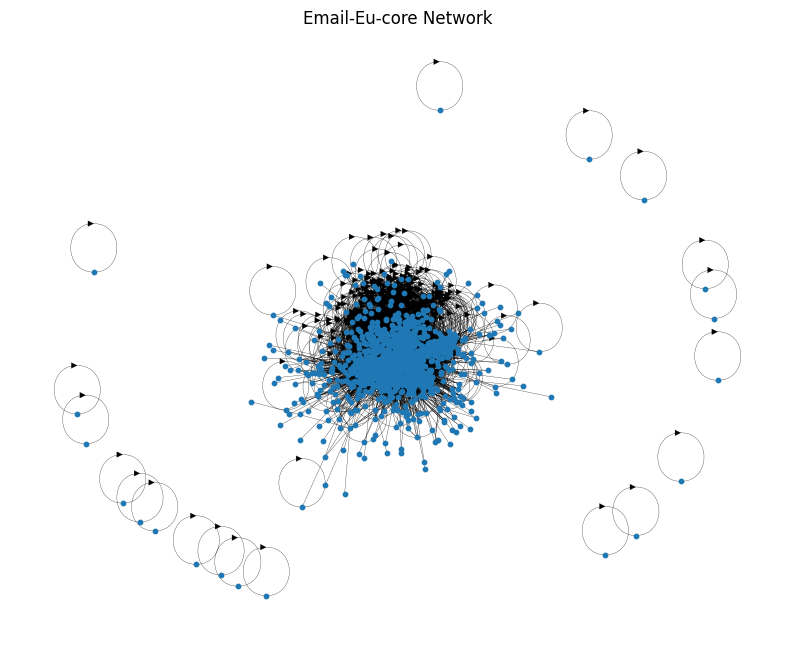

In [8]:
plt.figure(figsize=(10, 8))

pos = nx.spring_layout(G, seed=42)

nx.draw_networkx(
    G,
    pos,
    node_size=10,
    with_labels=False,
    arrows=False,
    width=0.2
)

plt.title("Email-Eu-core Network")
plt.axis("off")
plt.show()

# 2. Research Question and Hypotheses

## 2.1 Network Mechanism: Homophily

The network mechanism investigated in this laboratory is **homophily**.

Homophily refers to the tendency of actors with similar characteristics to form relationships with one another.

In the Email-Eu-core network, each member belongs to one of 42 departments. The analysis therefore investigates whether members connected by email are more likely to belong to the same department than would be expected under random assignment of department labels.

## 2.2 Research Question

**Are members of the same department connected by email more often than would be expected under random assignment of department labels?**

## 2.3 Hypotheses

### Null Hypothesis (H₀)

Department labels are unrelated to the observed email network structure.

The proportion of email relationships connecting members of the same department should therefore be similar to what would be expected if department labels were randomly assigned to the network nodes.

### Alternative Hypothesis (H₁)

Members of the same department are connected by email more frequently than expected under random assignment of department labels.

This would be consistent with a departmental homophily pattern.

## 2.4 Network Statistic

The statistic used to evaluate departmental homophily is the **proportion of directed email relationships connecting members from the same department**.

For every directed edge from member *i* to member *j*:

- the edge is counted as a same-department edge if department(i) = department(j);
- otherwise, it is counted as a different-department edge.

The observed statistic is therefore:

**Same-department proportion = Same-department edges / Total email relationships**

The observed statistic will later be compared with a null distribution obtained by randomly permuting department labels while keeping the observed network structure unchanged.

In [9]:
department_map = labels.set_index("node")["department"]

print("Department information loaded for", len(department_map), "nodes.")

Department information loaded for 1005 nodes.


In [10]:
edges_with_department = edges.copy()

edges_with_department["department_source"] = (
    edges_with_department["source"].map(department_map)
)

edges_with_department["department_target"] = (
    edges_with_department["target"].map(department_map)
)

print(
    "Missing department values:",
    edges_with_department[
        ["department_source", "department_target"]
    ].isna().sum().sum()
)

edges_with_department.head()

Missing department values: 0


,source,target,department_source,department_target
0,0,1,1,1
1,2,3,21,21
2,2,4,21,21
3,5,6,25,25
4,5,7,25,14


## 2.5 Observed Homophily Statistic

The department labels are now compared across the two endpoints of each directed email relationship.

An email relationship is considered a **same-department relationship** when the sender and recipient belong to the same department.

The proportion of same-department relationships represents the observed level of departmental homophily in the network.

In [11]:
edges_with_department["same_department"] = (
    edges_with_department["department_source"]
    == edges_with_department["department_target"]
)

observed_same_edges = (
    edges_with_department["same_department"].sum()
)

total_edges = len(edges_with_department)

observed_same_proportion = (
    observed_same_edges / total_edges
)

print("Same-department edges:", observed_same_edges)
print("Total email relationships:", total_edges)
print(
    "Observed same-department proportion:",
    round(observed_same_proportion, 4)
)
print(
    "Observed same-department percentage:",
    round(observed_same_proportion * 100, 2),
    "%"
)

Same-department edges: 9287
Total email relationships: 25571
Observed same-department proportion: 0.3632
Observed same-department percentage: 36.32 %


## 2.6 Observed Homophily

In the observed Email-Eu-core network, **9,287 of the 25,571 email relationships** connect members from the same department.

This corresponds to a same-department proportion of **0.3632**, or **36.32%**.

This indicates that a substantial proportion of email relationships occur between members of the same department. However, this value alone does not establish homophily because the department sizes are not equal.

Therefore, the observed statistic must be compared with a null model in which department labels are randomly reassigned while the network structure and department frequencies are preserved.

# 3. Null / Reference Model

## 3.1 Label-Permutation Null Model

A **label-permutation null model** is used to test whether the observed same-department connections are unusual.

The observed Email-Eu-core network is kept unchanged. The 1,005 nodes and 25,571 directed email relationships remain exactly the same.

The department labels are randomly shuffled among the nodes.

### What is preserved?

The null model preserves:

- all 1,005 nodes;
- all 25,571 directed email relationships;
- the complete network topology;
- each node's network connections;
- the total number of nodes in each department.

### What is randomized?

Only the assignment of department labels to the nodes is randomized.

### Why is this appropriate?

If department membership is unrelated to the observed email relationships, randomly assigning the existing department labels should produce same-department proportions that are compatible with the null hypothesis.

The observed statistic can therefore be compared with the distribution generated by these random permutations.

In [12]:
target_labels = labels["department"].to_numpy()

node_to_position = pd.Series(
    np.arange(len(labels)),
    index=labels["node"]
)

edge_source = (
    edges["source"]
    .map(node_to_position)
    .to_numpy()
)

edge_target = (
    edges["target"]
    .map(node_to_position)
    .to_numpy()
)

print("Number of department labels:", len(target_labels))
print("Number of source nodes:", len(edge_source))
print("Number of target nodes:", len(edge_target))

Number of department labels: 1005
Number of source nodes: 25571
Number of target nodes: 25571


## 3.2 Permutation Procedure

The department labels are randomly permuted **2,000 times**.

For each permutation:

1. The network structure remains unchanged.
2. Department labels are randomly reassigned to the nodes.
3. The proportion of same-department email relationships is calculated.
4. The resulting statistic is stored.

The 2,000 simulated values form the null/reference distribution.

In [13]:
n_permutations = 2000

rng = np.random.default_rng(42)

null_proportions = np.empty(n_permutations)

for i in range(n_permutations):

    permuted_labels = rng.permutation(target_labels)

    same_department = (
        permuted_labels[edge_source]
        == permuted_labels[edge_target]
    )

    null_proportions[i] = same_department.mean()

print("Number of permutations:", n_permutations)

Number of permutations: 2000


## 3.3 Null Distribution

The 2,000 permuted values represent the distribution of the same-department proportion expected under the null hypothesis.

The observed value of **0.3632** will be compared with this null distribution to determine whether the observed departmental homophily is unusually high.

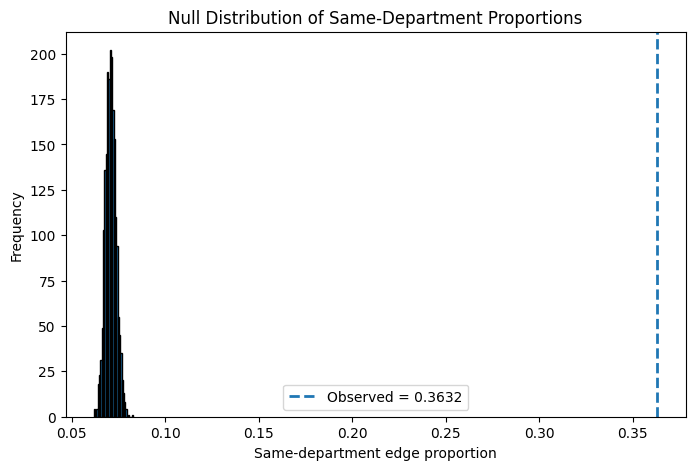

In [14]:
plt.figure(figsize=(8, 5))

plt.hist(
    null_proportions,
    bins=30,
    edgecolor="black"
)

plt.axvline(
    observed_same_proportion,
    linestyle="--",
    linewidth=2,
    label=f"Observed = {observed_same_proportion:.4f}"
)

plt.xlabel("Same-department edge proportion")
plt.ylabel("Frequency")
plt.title("Null Distribution of Same-Department Proportions")
plt.legend()
plt.show()

## 3.4 Statistical Inference

The observed same-department proportion is **0.3632**, while the null distribution is concentrated at substantially lower values.

A one-sided permutation test is used to determine how frequently a randomly permuted network produces a same-department proportion at least as large as the observed value.

In [15]:
extreme_count = np.sum(
    null_proportions >= observed_same_proportion
)

p_value = (
    (extreme_count + 1)
    / (n_permutations + 1)
)

print("Observed statistic:", round(observed_same_proportion, 4))
print("Extreme permutations:", extreme_count)
print("Permutation p-value:", p_value)

Observed statistic: 0.3632
Extreme permutations: 0
Permutation p-value: 0.0004997501249375312


### Interpretation of the Statistical Test

The permutation test produced a p-value of **0.00050**. None of the 2,000 random permutations produced a same-department proportion as large as the observed value of **0.3632**.

This provides strong evidence against the null hypothesis that department labels are unrelated to the email network structure. Under the selected label-permutation null model, the observed same-department connections are therefore unusually high.

The result is consistent with **departmental homophily** in the Email-Eu-core network. However, this test does not establish that department membership causes the observed communication pattern. Other factors, such as shared projects, organizational roles, supervisors, or physical location, may also contribute to the observed structure.

# 5. AI Use Statement

Generative AI tools were used to support the preparation of this laboratory work specifically ChatGPT(Gpt-GO)

The AI assistant was used to help structure the analysis, clarify the concepts of hypothesis testing and network homophily, and assist with Python code for the permutation test and visualization.

The prompts focused on the laboratory requirements, the Email-Eu-core dataset, the selected homophily mechanism, the formulation of hypotheses, and the implementation of the label-permutation null model.

The generated code and explanations were reviewed, executed, and verified using the actual dataset. The final statistical results, including the observed statistic, null distribution, and permutation p-value, were obtained from the executed Python notebook.

The methodological interpretation was also reviewed to ensure that the results were not presented as causal evidence.

# 6. Conclusion

This laboratory investigated whether departmental homophily is present in the Email-Eu-core email network.

The observed proportion of same-department email relationships was **36.32%**. A label-permutation null model was used to generate **2,000 reference networks** while preserving the network topology and the department-size distribution.

The observed statistic was substantially higher than the values generated under the null model. The permutation test produced a **p-value of 0.00050**, with none of the 2,000 permutations producing a statistic as large as the observed value.

These results are consistent with departmental homophily in the Email-Eu-core network. However, the analysis does not establish causation, since other organizational factors may also influence email communication patterns.

Overall, the observed network structure is not consistent with what would be expected from randomly assigned department labels under the selected null model.